# Linear Regression Analysis (R)

This notebook loads salary-vs-experience data, explores the relationship with a scatter plot, fits a simple linear regression model (`y = mx + b`), overlays the fitted line with equation and correlation annotations, and reports slope, intercept, Pearson's *r*, and mean squared error (MSE).


## Setup

Load `ggplot2` for plotting. Base R provides data loading, model fitting, and metrics.


In [1]:
# Plotting library for scatter plots and regression overlays
library(ggplot2)


## Load the data

`regression_data.csv` contains two columns: `YearsExperience` (predictor) and `Salary` (response). We inspect the first rows, dimensions, and structure.


In [2]:
# Load salary vs. years of experience
df <- read.csv("regression_data.csv", stringsAsFactors = FALSE)

print("First rows:")
print(head(df))
print(paste("\nDimensions:", nrow(df), "rows,", ncol(df), "columns"))
print("\nStructure:")
str(df)


[1] "First rows:"


  YearsExperience Salary
1             1.1  39343
2             1.3  46205
3             1.5  37731
4             2.0  43525
5             2.2  39891
6             2.9  56642


[1] "\nDimensions: 10 rows, 2 columns"


[1] "\nStructure:"


'data.frame':	10 obs. of  2 variables:
 $ YearsExperience: num  1.1 1.3 1.5 2 2.2 2.9 3 3.2 3.7 4
 $ Salary         : num  39343 46205 37731 43525 39891 ...


## Exploratory scatter plot

A scatter plot of salary against years of experience helps check whether a linear relationship looks plausible before fitting a model.


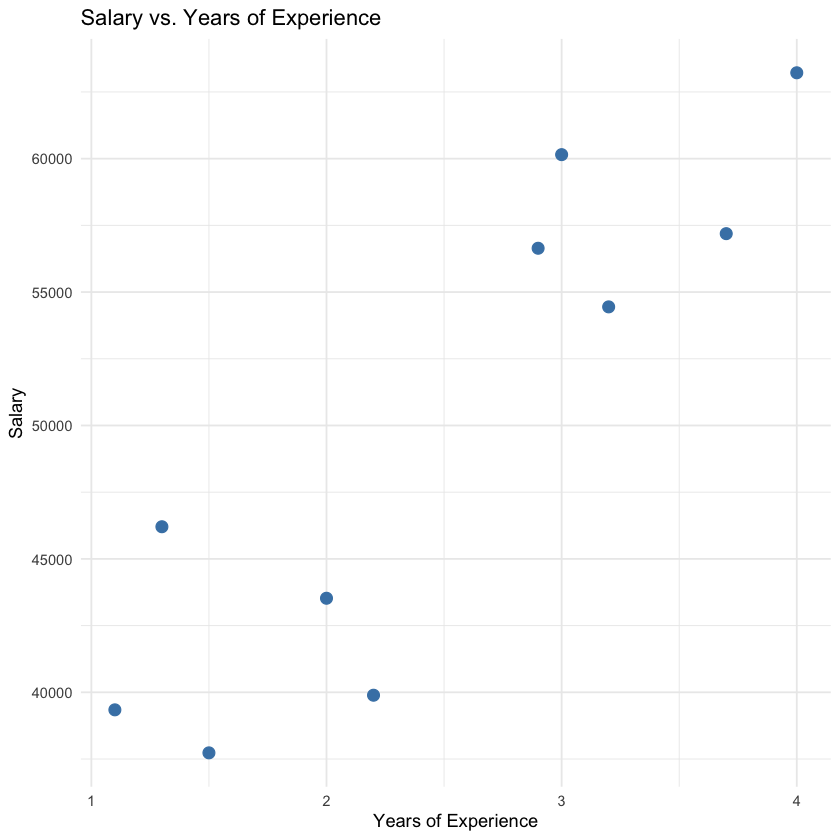

In [3]:
# Visual check of the relationship between experience and salary
ggplot(df, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "steelblue", size = 3) +
  labs(
    x = "Years of Experience",
    y = "Salary",
    title = "Salary vs. Years of Experience"
  ) +
  theme_minimal()


## Fit the linear regression model

We fit `Salary ~ YearsExperience` using ordinary least squares. The model has the form **y = mx + b**, where **m** is the slope and **b** is the intercept. We also compute Pearson's correlation coefficient (*r*) and the mean squared error (MSE) between observed and predicted salaries.


In [4]:
# Fit ordinary least squares: Salary ~ YearsExperience
model <- lm(Salary ~ YearsExperience, data = df)

# Extract intercept (b) and slope (m) from the fitted line y = mx + b
intercept <- coef(model)[1]  # b
slope <- coef(model)[2]      # m

# Predicted salaries and evaluation metrics
y_pred <- predict(model, df)
y <- df$Salary
r <- cor(df$YearsExperience, df$Salary)  # Pearson's r (default)
mse <- mean((y - y_pred)^2)              # mean squared error

cat(sprintf("Slope (m):              %.2f\n", slope))
cat(sprintf("Intercept (b):          %.2f\n", intercept))
cat(sprintf("Pearson's r:            %.4f\n", r))
cat(sprintf("Mean Squared Error:     %.2f\n", mse))
cat(sprintf("Equation:               y = %.2fx + %.2f\n", slope, intercept))


Slope (m):              8285.29


Intercept (b):          29203.52


Pearson's r:            0.8861


Mean Squared Error:     17523844.08


Equation:               y = 8285.29x + 29203.52


## Regression plot with annotations

Overlay the fitted regression line on the scatter plot and annotate the plot with the equation **y = mx + b** (using the fitted slope and intercept) and Pearson's *r*.


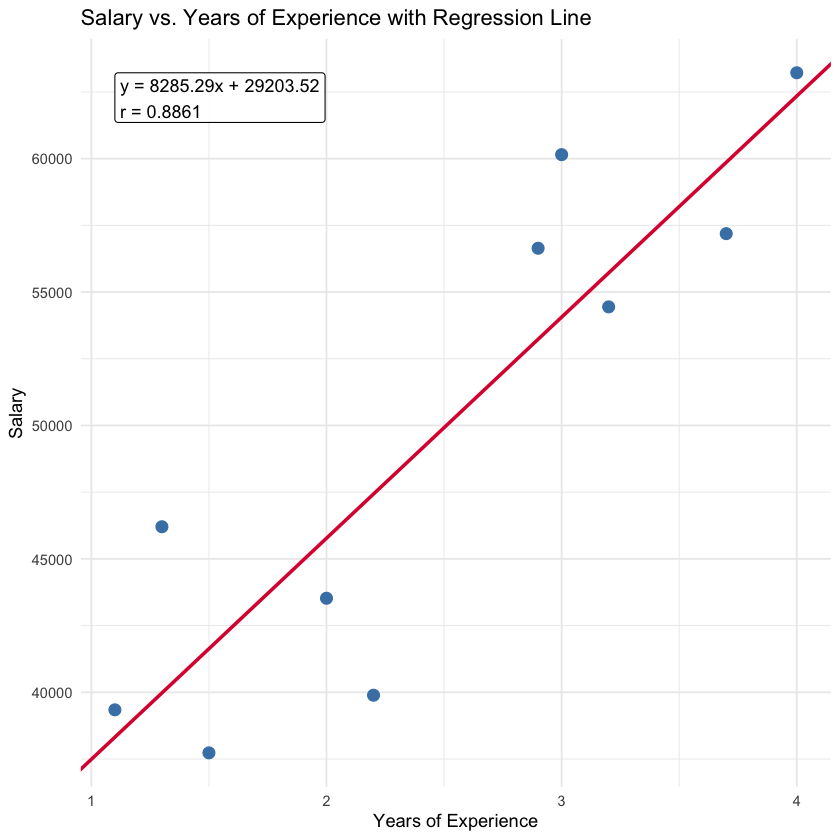

In [5]:
# Annotation text: fitted equation and correlation
annotation <- sprintf("y = %.2fx + %.2f\nr = %.4f", slope, intercept, r)

# Place equation and r near the upper-left of the data range
ggplot(df, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "steelblue", size = 3) +
  geom_abline(intercept = intercept, slope = slope, color = "#DC143C", linewidth = 1) +
  annotate(
    "label",
    x = min(df$YearsExperience),
    y = max(df$Salary),
    label = annotation,
    hjust = 0,
    vjust = 1,
    size = 3.8,
    fill = "white",
    linewidth = 0.3,
    alpha = 0.9
  ) +
  labs(
    x = "Years of Experience",
    y = "Salary",
    title = "Salary vs. Years of Experience with Regression Line"
  ) +
  theme_minimal()


## Interpretation

- **Slope (`m`)**: The expected change in salary for each additional year of experience. A positive slope means salary tends to increase as experience increases.
- **Intercept (`b`)**: The predicted salary when years of experience is 0. This is the model's baseline; it may fall outside the range of observed experience values, so treat it as a mathematical intercept rather than a literal entry-level salary unless 0 years is in the data.
- **Pearson's correlation coefficient (`r`)**: Measures the strength and direction of the linear association between years of experience and salary. Values range from −1 to 1; values near 1 indicate a strong positive linear relationship.
- **Mean Squared Error (MSE)**: The average of the squared differences between observed and predicted salaries. Smaller MSE means predictions are closer to the observed values (units are salary squared).
